In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
import os

print("Current working dir:", os.getcwd())
print("Files here:", os.listdir())

Current working dir: c:\Users\GIGABYTE\Desktop\binge-eating-risk-prediction\notebooks
Files here: ['binge_eating_analysis.ipynb']


In [5]:
df = pd.read_excel("../data/data.xlsx")
df.head()

,Age,"Gender(0,1)",BMI,Weight(kg),Waist(cm),"Eduction(0,1,2)",Alcohol,T2D,Sleep apnea syndrome,Gastroesophageal reflux disease,EDE-Q score (Per-operation),EDE-Q score (12 months),EDE-Q score (18 months),EDE-Q score (24 months),group
0,30.360723,0,35.316402,82.802246,102.970086,2,1,1,1,0,3.235297,2.074239,1.700481,1.088553,1
1,28.566011,0,31.054477,84.617723,91.468454,1,1,0,1,1,3.016742,2.909311,1.771950,1.340691,1
2,42.887383,0,33.664064,83.194969,100.789294,2,1,1,1,1,3.216128,1.657460,1.866296,0.990808,1
3,31.335238,1,29.495937,103.433760,119.337946,2,1,1,1,1,2.935736,1.335888,2.191789,2.830876,1
4,26.542677,0,43.735520,65.345939,103.051870,2,1,1,1,1,4.057778,2.205433,2.719019,0.431271,1


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["group"].value_counts())

Shape: (272, 15)

Columns:
['Age', 'Gender(0,1)', 'BMI', 'Weight(kg)', 'Waist(cm)', 'Eduction(0,1,2)', 'Alcohol', 'T2D', 'Sleep apnea syndrome', 'Gastroesophageal reflux disease', 'EDE-Q score (Per-operation)', 'EDE-Q score (12 months)', 'EDE-Q score (18 months)', 'EDE-Q score (24 months)', 'group']

Data types:
Age                                float64
Gender(0,1)                          int64
BMI                                float64
Weight(kg)                         float64
Waist(cm)                          float64
Eduction(0,1,2)                      int64
Alcohol                              int64
T2D                                  int64
Sleep apnea syndrome                 int64
Gastroesophageal reflux disease      int64
EDE-Q score (Per-operation)        float64
EDE-Q score (12 months)            float64
EDE-Q score (18 months)            float64
EDE-Q score (24 months)            float64
group                                int64
dtype: object

Missing values:
Age       

In [7]:
X = df.drop("group", axis=1)
y = df["group"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (272, 14)
y shape: (272,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (217, 14)
Test size: (55, 14)


In [9]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", random_state=42))
])

In [10]:
log_model.fit(X_train, y_train)
import joblib
joblib.dump(log_model, "binge_eating_model.joblib")

['binge_eating_model.joblib']

In [11]:
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.9272727272727272

Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.89        17
           1       1.00      0.89      0.94        38

    accuracy                           0.93        55
   macro avg       0.90      0.95      0.92        55
weighted avg       0.94      0.93      0.93        55


ROC-AUC: 0.9938080495356036


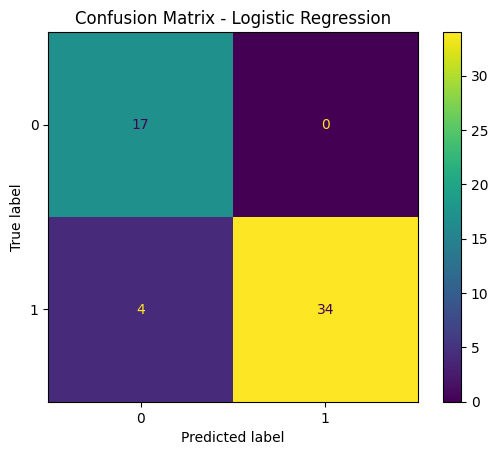

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

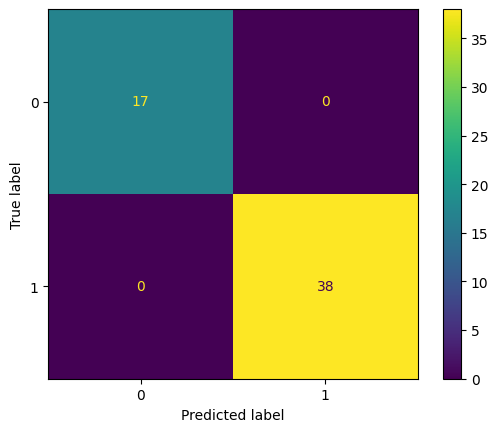

In [32]:
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.show()

In [33]:
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nROC-AUC:", roc_auc_score(y_test, rf_proba))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        38

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55


ROC-AUC: 1.0


In [34]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, rf_proba)
    ]
})

results

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.927273,0.993808
1,Random Forest,1.000000,1.000000


In [35]:
cols_to_drop = [
    "EDE-Q score (12 months)",
    "EDE-Q score (18 months)",
    "EDE-Q score (24 months)"
]

X2 = df.drop(["group"] + cols_to_drop, axis=1)
y2 = df["group"]

print(X2.columns)

Index(['Age', 'Gender(0,1)', 'BMI', 'Weight(kg)', 'Waist(cm)',
       'Eduction(0,1,2)', 'Alcohol', 'T2D', 'Sleep apnea syndrome',
       'Gastroesophageal reflux disease', 'EDE-Q score (Per-operation)'],
      dtype='object')


In [36]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

In [37]:
log_model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", random_state=42))
])

log_model2.fit(X2_train, y2_train)

y2_pred = log_model2.predict(X2_test)
y2_proba = log_model2.predict_proba(X2_test)[:, 1]

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y2_test, y2_pred))
print(classification_report(y2_test, y2_pred))
print("ROC-AUC:", roc_auc_score(y2_test, y2_proba))

Logistic Regression Results:
Accuracy: 0.9272727272727272
              precision    recall  f1-score   support

           0       0.81      1.00      0.89        17
           1       1.00      0.89      0.94        38

    accuracy                           0.93        55
   macro avg       0.90      0.95      0.92        55
weighted avg       0.94      0.93      0.93        55

ROC-AUC: 0.9938080495356036


In [38]:
rf_model2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model2.fit(X2_train, y2_train)

rf2_pred = rf_model2.predict(X2_test)
rf2_proba = rf_model2.predict_proba(X2_test)[:, 1]

print("\nRandom Forest Results:")
print("Accuracy:", accuracy_score(y2_test, rf2_pred))
print(classification_report(y2_test, rf2_pred))
print("ROC-AUC:", roc_auc_score(y2_test, rf2_proba))


Random Forest Results:
Accuracy: 0.9818181818181818
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        17
           1       0.97      1.00      0.99        38

    accuracy                           0.98        55
   macro avg       0.99      0.97      0.98        55
weighted avg       0.98      0.98      0.98        55

ROC-AUC: 1.0


In [44]:
results2 = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y2_test, y2_pred),
        accuracy_score(y2_test, rf2_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y2_test, y2_proba),
        roc_auc_score(y2_test, rf2_proba)
    ]
})

results2

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.927273,0.993808
1,Random Forest,0.981818,1.000000


In [40]:
print(X2.columns)

Index(['Age', 'Gender(0,1)', 'BMI', 'Weight(kg)', 'Waist(cm)',
       'Eduction(0,1,2)', 'Alcohol', 'T2D', 'Sleep apnea syndrome',
       'Gastroesophageal reflux disease', 'EDE-Q score (Per-operation)'],
      dtype='object')


In [41]:
importances = pd.Series(rf_model2.feature_importances_, index=X2.columns)
importances = importances.sort_values(ascending=False)

print(importances)

EDE-Q score (Per-operation)        0.786091
Waist(cm)                          0.049895
Age                                0.044847
BMI                                0.043806
Weight(kg)                         0.035621
Eduction(0,1,2)                    0.013571
T2D                                0.006392
Alcohol                            0.005729
Sleep apnea syndrome               0.005668
Gender(0,1)                        0.004500
Gastroesophageal reflux disease    0.003879
dtype: float64


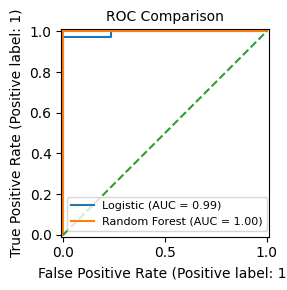

In [42]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 3))

RocCurveDisplay.from_predictions(y_test, log_model.predict_proba(X_test)[:, 1],
                                 name="Logistic", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_model.predict_proba(X_test)[:, 1],
                                 name="Random Forest", ax=ax)

ax.plot([0, 1], [0, 1], "--")
ax.set_title("ROC Comparison", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [45]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results_table_no_leakage = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y2_test, y2_pred),
        accuracy_score(y2_test, rf2_pred)
    ],
    "Precision": [
        precision_score(y2_test, y2_pred),
        precision_score(y2_test, rf2_pred)
    ],
    "Recall": [
        recall_score(y2_test, y2_pred),
        recall_score(y2_test, rf2_pred)
    ],
    "F1 Score": [
        f1_score(y2_test, y2_pred),
        f1_score(y2_test, rf2_pred)
    ],
    "AUC": [
        roc_auc_score(y2_test, y2_proba),
        roc_auc_score(y2_test, rf2_proba)
    ]
}).round(4)

results_table_no_leakage

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.9273,1.0000,0.8947,0.9444,0.9938
1,Random Forest,0.9818,0.9744,1.0000,0.9870,1.0000
